# IMPORTATION DES BIBLIOTHEQUES

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

# CHARGEMENT DES DONNEES

In [3]:
#Chargement des données
data = pd.read_csv('AmesHousing.csv')
#Afficchage des cinqs premieres lignes
print(data.head())


   Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0      1  526301100           20        RL         141.0     31770   Pave   
1      2  526350040           20        RH          80.0     11622   Pave   
2      3  526351010           20        RL          81.0     14267   Pave   
3      4  526353030           20        RL          93.0     11160   Pave   
4      5  527105010           60        RL          74.0     13830   Pave   

  Alley Lot Shape Land Contour  ... Pool Area Pool QC  Fence Misc Feature  \
0   NaN       IR1          Lvl  ...         0     NaN    NaN          NaN   
1   NaN       Reg          Lvl  ...         0     NaN  MnPrv          NaN   
2   NaN       IR1          Lvl  ...         0     NaN    NaN         Gar2   
3   NaN       Reg          Lvl  ...         0     NaN    NaN          NaN   
4   NaN       IR1          Lvl  ...         0     NaN  MnPrv          NaN   

  Misc Val Mo Sold Yr Sold Sale Type  Sale Condition  SalePrice  
0       

# PRETRAITEMENT DES DONNEES

## 1. Information sur les donnees

In [7]:
# Vérifier les types de données et les valeurs manquantes
print(data.info())  
# Statistiques descriptives
print(data.describe())  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

## 2. Visualisation des corrélations

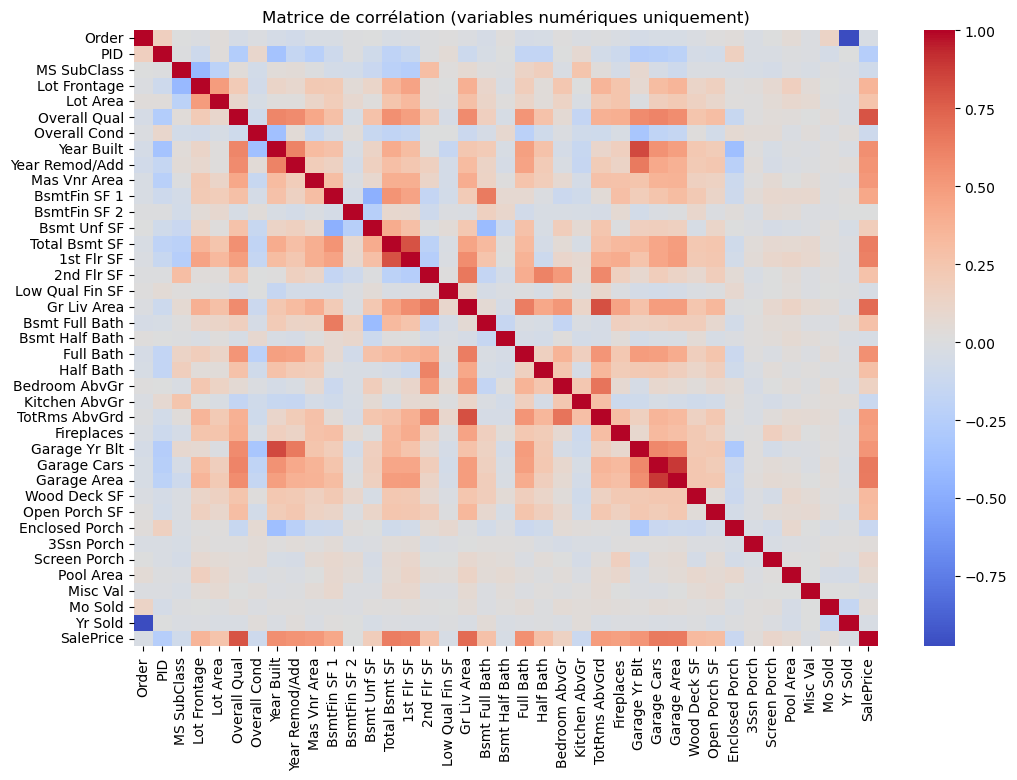

In [9]:
# Filtrer les colonnes numériques
numeric_data = data.select_dtypes(include=['int64', 'float64'])

# Calculer la matrice de corrélation
corr_matrix = numeric_data.corr()

# Afficher la heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False)
plt.title("Matrice de corrélation (variables numériques uniquement)")
plt.show()

## 3. Séparation des features et de la target

In [10]:
X = data.drop('SalePrice', axis=1)
y = data['SalePrice']

## 4. Identification des colonnes numériques et catégorielles


In [11]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

## 5. Imputation des valeurs maquantes et normalisation

In [12]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  
    ('scaler', StandardScaler())  
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  
    ('onehot', OneHotEncoder(handle_unknown='ignore'))  
])

## 6. Transformation des colonnes et application du pretraitement

In [13]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Division en train/test: 20% en test et 80% en train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Application du prétraitement
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

# CREATION DES MODELS

In [14]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42)
}


# ENTRAINEMENT ET EVALUATION 

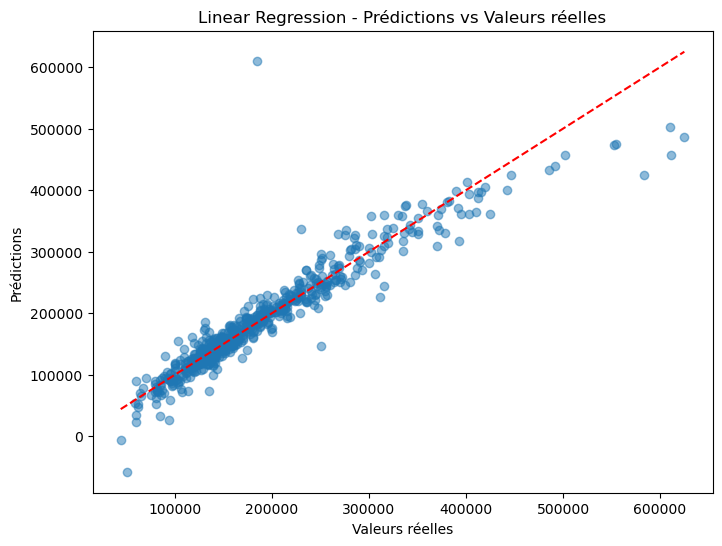

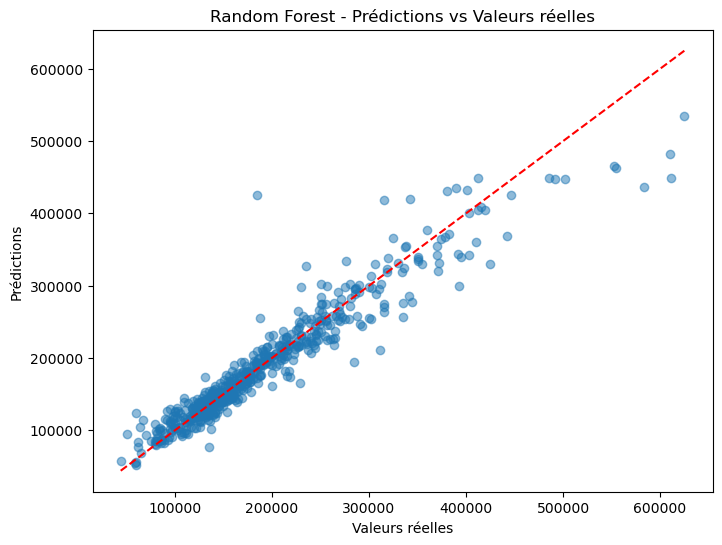

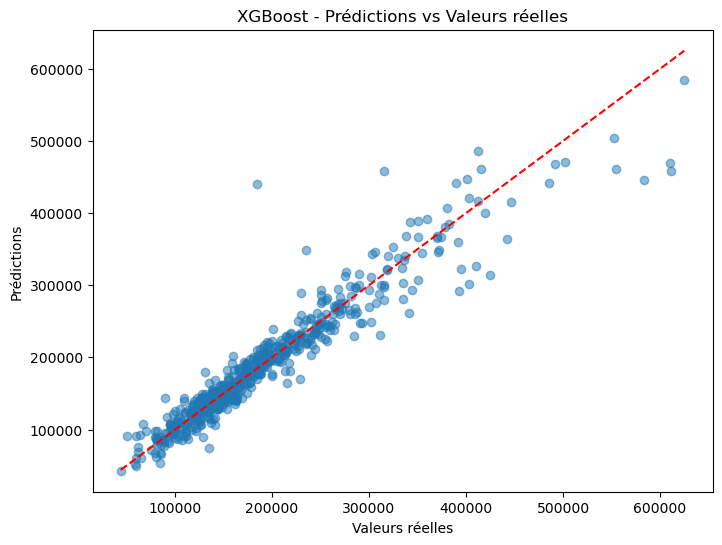

In [16]:
# Entraînement et évaluation des modèles
results = {}
for name, model in models.items():
    # Entraînement du modèle
    model.fit(X_train, y_train)  
    # Prédictions
    y_pred = model.predict(X_test)  
    # Calcul du RMSE
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))  
    # Calcul du R²
    r2 = r2_score(y_test, y_pred)  
    results[name] = {"RMSE": rmse, "R²": r2}

    # Affichage des prédictions vs valeurs réelles
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel('Valeurs réelles')
    plt.ylabel('Prédictions')
    plt.title(f'{name} - Prédictions vs Valeurs réelles')
    plt.show()

# COMPARAISON DES PERFORMANCES DES MODELS

In [17]:
print("\nComparaison des performances des modèles :")
for name, metrics in results.items():
    print(f"{name}: RMSE = {metrics['RMSE']:.2f}, R² = {metrics['R²']:.2f}")


Comparaison des performances des modèles :
Linear Regression: RMSE = 29635.95, R² = 0.89
Random Forest: RMSE = 26622.57, R² = 0.91
XGBoost: RMSE = 26467.56, R² = 0.91


# IDENTIFICATION DU MODEL OPTIMAL

In [19]:
best_model = min(results, key=lambda x: results[x]['RMSE'])
print(f"\nLe modèle optimal est : {best_model} avec un plus faible RMSE de {results[best_model]['RMSE']:.2f}")


Le modèle optimal est : XGBoost avec un plus faible RMSE de 26467.56


# CONCLUSION